In [3]:
import pandas as pd

df = pd.read_csv("..\\subscription_dataset.csv")
df.head()

,CustomerID,TransactionID,Date,Description,Merchant,Amount,Balance,SubscriptionFlag
0,C1,T1,2025-01-01,Payment to Cafe Coffee Day,Cafe Coffee Day,-1889,6136,0
1,C1,T2,2025-01-01,Payment to Flipkart,Flipkart,-955,5181,0
2,C1,T3,2025-01-02,Salary Credit,Employer,49954,55135,0
3,C1,T4,2025-01-02,Payment to Reliance Smart,Reliance Smart,-1582,53553,0
4,C1,T5,2025-01-02,Payment to Petrol Pump,Petrol Pump,-1257,52296,0


In [6]:
#  Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df

,CustomerID,TransactionID,Date,Description,Merchant,Amount,Balance,SubscriptionFlag
0,C1,T1,2025-01-01,Payment to Cafe Coffee Day,Cafe Coffee Day,-1889,6136,0
1,C1,T2,2025-01-01,Payment to Flipkart,Flipkart,-955,5181,0
2,C1,T3,2025-01-02,Salary Credit,Employer,49954,55135,0
3,C1,T4,2025-01-02,Payment to Reliance Smart,Reliance Smart,-1582,53553,0
4,C1,T5,2025-01-02,Payment to Petrol Pump,Petrol Pump,-1257,52296,0
...,...,...,...,...,...,...,...,...
99191,C500,T99192,2025-06-27,Payment to DMart,DMart,-565,27702,0
99192,C500,T99193,2025-06-28,Payment to Uber,Uber,-842,26860,0
99193,C500,T99194,2025-06-28,Payment to DMart,DMart,-901,25959,0
99194,C500,T99195,2025-06-29,Payment to Flipkart,Flipkart,-1086,24873,0


In [ ]:
# Ensure Amount & Balance are numeric
df['Amount'] = pd.to_numeric(df['Amount'])
df['Balance'] = pd.to_numeric(df['Balance'])

In [7]:
df = df.sort_values(by=['CustomerID', 'Date', 'TransactionID'])

In [8]:
# Add Derived Columns
# Month
df['Month'] = df['Date'].dt.to_period('M')


In [10]:
# Day of week
df['DayOfWeek'] = df['Date'].dt.day_name()

In [11]:
# Transaction type (Credit / Debit)
df['TransactionType'] = df['Amount'].apply(lambda x: 'Credit' if x > 0 else 'Debit')

In [13]:
def categorize(merchant):
    if merchant in ['Swiggy', 'Zomato', 'Cafe Coffee Day']:
        return 'Food'
    if merchant in ['Flipkart', 'DMart', 'Reliance Smart']:
        return 'Shopping'
    if merchant == 'Uber':
        return 'Transport'
    if merchant == 'Petrol Pump':
        return 'Fuel'
    if merchant == 'Electricity Bill':
        return 'Utility'
    if merchant in ['Netflix', 'Amazon Prime', 'Spotify', 'Gym Membership']:
        return 'Subscription'
    return 'Others'

df['Category'] = df['Merchant'].apply(categorize)

In [14]:
# Check for Missing Values / Duplicates
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [15]:
# If duplicates exist:
df = df.drop_duplicates()

In [22]:
# Save the Cleaned Dataset
df.to_csv("..\\data\\subscription_dataset_cleaned.csv", index=False)

In [24]:

df.head()

,CustomerID,TransactionID,Date,Description,Merchant,Amount,Balance,SubscriptionFlag,Month,DayOfWeek,TransactionType,Category
0,C1,T1,2025-01-01,Payment to Cafe Coffee Day,Cafe Coffee Day,-1889,6136,0,2025-01,Wednesday,Debit,Food
1,C1,T2,2025-01-01,Payment to Flipkart,Flipkart,-955,5181,0,2025-01,Wednesday,Debit,Shopping
2,C1,T3,2025-01-02,Salary Credit,Employer,49954,55135,0,2025-01,Thursday,Credit,Others
3,C1,T4,2025-01-02,Payment to Reliance Smart,Reliance Smart,-1582,53553,0,2025-01,Thursday,Debit,Shopping
4,C1,T5,2025-01-02,Payment to Petrol Pump,Petrol Pump,-1257,52296,0,2025-01,Thursday,Debit,Fuel


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99196 entries, 0 to 19744
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        99196 non-null  object        
 1   TransactionID     99196 non-null  object        
 2   Date              99196 non-null  datetime64[ns]
 3   Description       99196 non-null  object        
 4   Merchant          99196 non-null  object        
 5   Amount            99196 non-null  int64         
 6   Balance           99196 non-null  int64         
 7   SubscriptionFlag  99196 non-null  int64         
 8   Month             99196 non-null  period[M]     
 9   DayOfWeek         99196 non-null  object        
 10  TransactionType   99196 non-null  object        
 11  Category          99196 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(7), period[M](1)
memory usage: 9.8+ MB


In [27]:
df.describe()

,Date,Amount,Balance,SubscriptionFlag
count,99196,99196.000000,99196.000000,99196.000000
mean,2025-03-31 00:39:10.836727296,52.828743,35044.943667,0.061575
min,2025-01-01 00:00:00,-2000.000000,14.000000,0.000000
25%,2025-02-14 00:00:00,-1500.000000,20569.000000,0.000000
50%,2025-03-31 00:00:00,-1005.000000,33565.500000,0.000000
75%,2025-05-15 00:00:00,-503.000000,47464.000000,0.000000
max,2025-06-29 00:00:00,49999.000000,122148.000000,1.000000
std,NaN,6379.415622,19937.334056,0.240383


In [28]:
df.isnull().sum()

CustomerID          0
TransactionID       0
Date                0
Description         0
Merchant            0
Amount              0
Balance             0
SubscriptionFlag    0
Month               0
DayOfWeek           0
TransactionType     0
Category            0
dtype: int64

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✔ Project paths set. Ready to load dataset.")


✔ Project paths set. Ready to load dataset.


In [35]:
df = pd.read_csv("..\\data\\subscription_dataset_cleaned.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,CustomerID,TransactionID,Date,Description,Merchant,Amount,Balance,SubscriptionFlag,Month,DayOfWeek,TransactionType,Category
0,C1,T1,2025-01-01,Payment to Cafe Coffee Day,Cafe Coffee Day,-1889,6136,0,2025-01,Wednesday,Debit,Food
1,C1,T2,2025-01-01,Payment to Flipkart,Flipkart,-955,5181,0,2025-01,Wednesday,Debit,Shopping
2,C1,T3,2025-01-02,Salary Credit,Employer,49954,55135,0,2025-01,Thursday,Credit,Others
3,C1,T4,2025-01-02,Payment to Reliance Smart,Reliance Smart,-1582,53553,0,2025-01,Thursday,Debit,Shopping
4,C1,T5,2025-01-02,Payment to Petrol Pump,Petrol Pump,-1257,52296,0,2025-01,Thursday,Debit,Fuel


In [37]:
print("Data Info:")
display(df.info())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99196 entries, 0 to 99195
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        99196 non-null  object
 1   TransactionID     99196 non-null  object
 2   Date              99196 non-null  object
 3   Description       99196 non-null  object
 4   Merchant          99196 non-null  object
 5   Amount            99196 non-null  int64 
 6   Balance           99196 non-null  int64 
 7   SubscriptionFlag  99196 non-null  int64 
 8   Month             99196 non-null  object
 9   DayOfWeek         99196 non-null  object
 10  TransactionType   99196 non-null  object
 11  Category          99196 non-null  object
dtypes: int64(3), object(9)
memory usage: 9.1+ MB


None

In [39]:
print("\nSummary Statistics:")
display(df.describe())



Summary Statistics:


,Amount,Balance,SubscriptionFlag
count,99196.000000,99196.000000,99196.000000
mean,52.828743,35044.943667,0.061575
std,6379.415622,19937.334056,0.240383
min,-2000.000000,14.000000,0.000000
25%,-1500.000000,20569.000000,0.000000
50%,-1005.000000,33565.500000,0.000000
75%,-503.000000,47464.000000,0.000000
max,49999.000000,122148.000000,1.000000


In [41]:
print("\nMissing Values:")
display(df.isnull().sum())



Missing Values:


CustomerID          0
TransactionID       0
Date                0
Description         0
Merchant            0
Amount              0
Balance             0
SubscriptionFlag    0
Month               0
DayOfWeek           0
TransactionType     0
Category            0
dtype: int64

In [43]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nUnique Values Per Column:")
df.nunique()


Rows: 99196
Columns: 12

Unique Values Per Column:


CustomerID            500
TransactionID       99196
Date                  180
Description            15
Merchant               15
Amount               4750
Balance             53023
SubscriptionFlag        2
Month                   6
DayOfWeek               7
TransactionType         2
Category                7
dtype: int64

### **Time-Based Analysis**


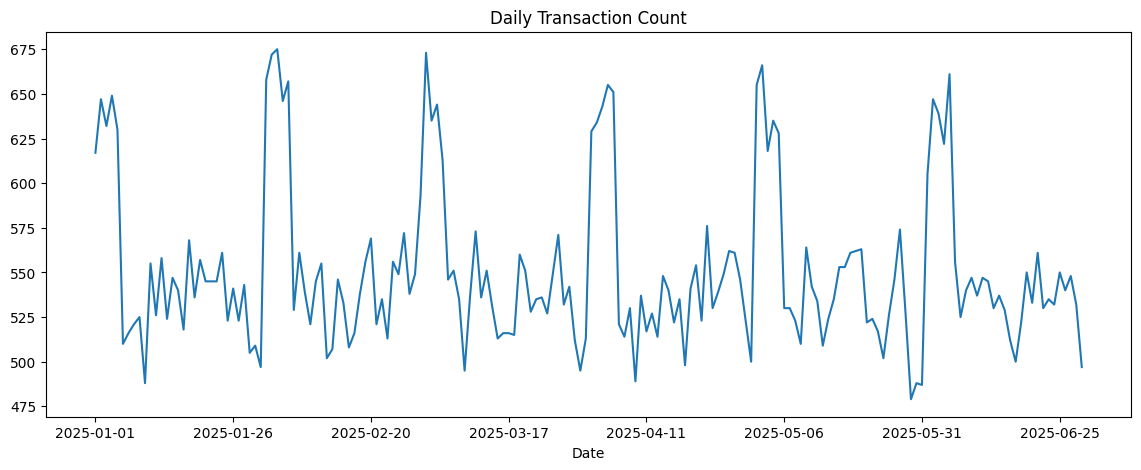

In [47]:
df.groupby("Date")["TransactionID"].count().plot(figsize=(14,5))
plt.title("Daily Transaction Count")
plt.show()

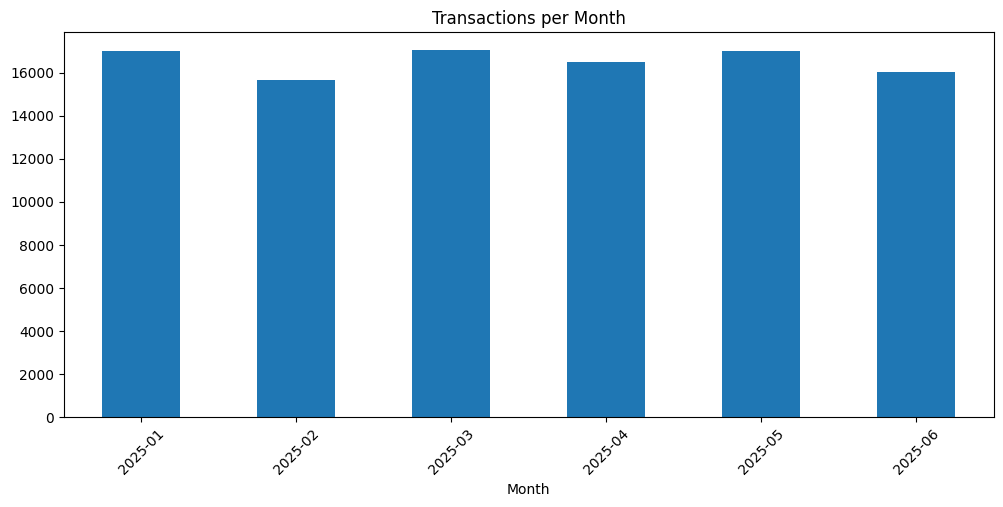

In [48]:
# Monthly Transaction Volume
df.groupby("Month")["TransactionID"].count().plot(kind="bar", figsize=(12,5), title="Transactions per Month")
plt.xticks(rotation=45)
plt.show()

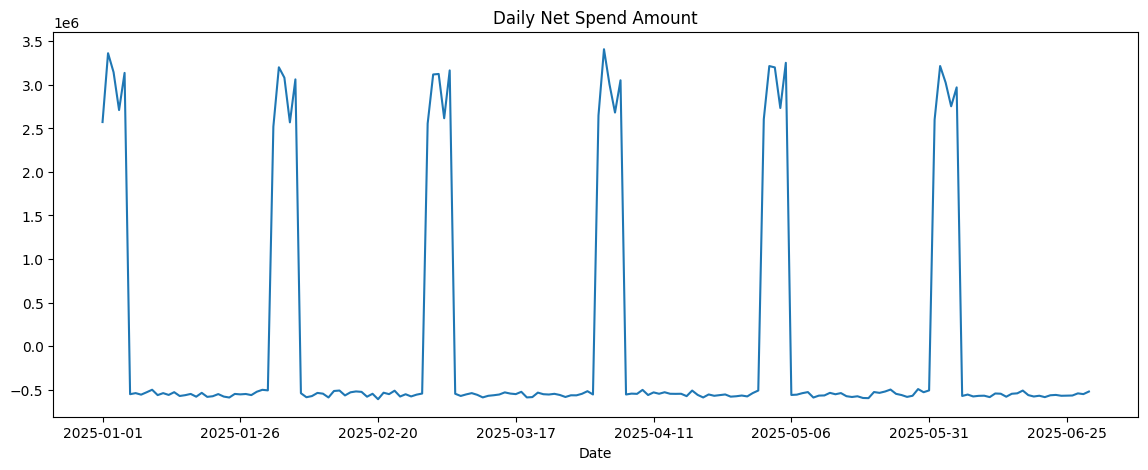

In [51]:
# Daily Net Spend Trend
df.groupby("Date")["Amount"].sum().plot(figsize=(14,5))
plt.title("Daily Net Spend Amount")
plt.show()

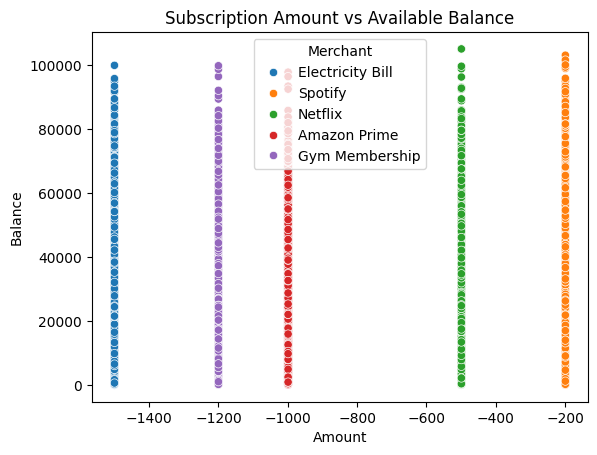

In [ ]:
# Balance vs Subscription Amount Impact
# Purpose: Show whether low balance correlates with subscription payments
# (e.g., Netflix/Spotify charges often hit when balance is low)
sns.scatterplot(data=df[df["SubscriptionFlag"]==1],
                x="Amount", y="Balance", hue="Merchant")
plt.title("Subscription Amount vs Available Balance")
plt.show()

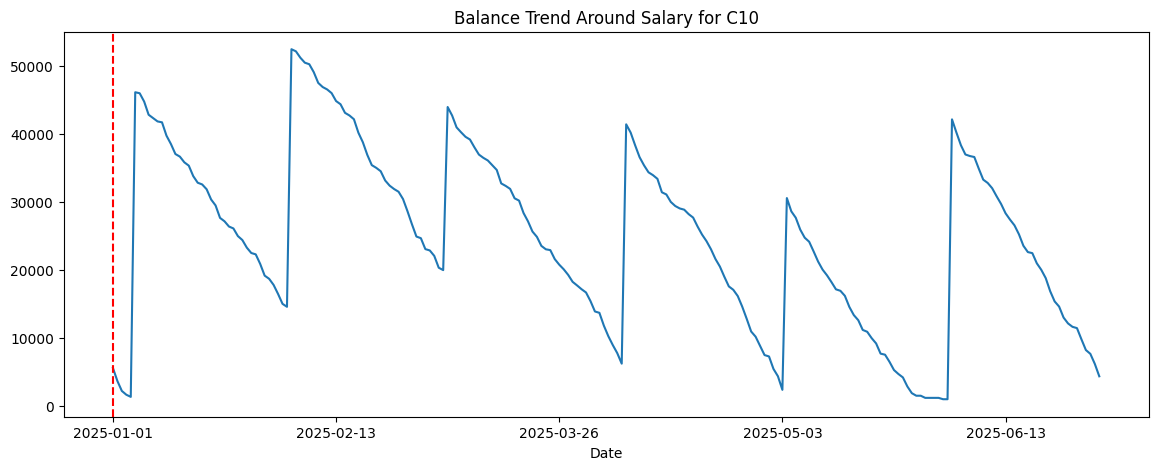

In [88]:
# Salary Credit Effect on Balance
# Purpose: Visualizes how balance behaves around salary day
customer = "C10"
subset = df[df["CustomerID"] == customer].set_index("Date")

subset["Balance"].plot(figsize=(14,5))
plt.axvline(subset[subset["Description"].str.contains("Salary")].index[0], color='r', linestyle='--')
plt.title("Balance Trend Around Salary for C10")
plt.show()

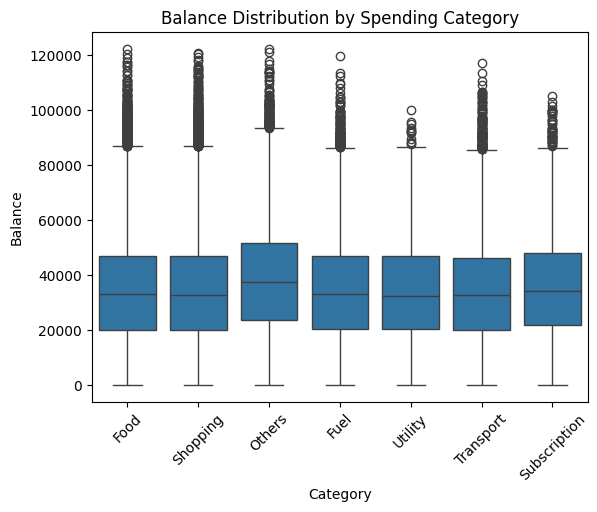

In [ ]:
# Spending Category vs Average Balance
# Purpose: Shows relationship between spending habits and balance health.

sns.boxplot(data=df, x="Category", y="Balance")
plt.title("Balance Distribution by Spending Category")
plt.xticks(rotation=45)
plt.show()

### **Subscription Analysis**

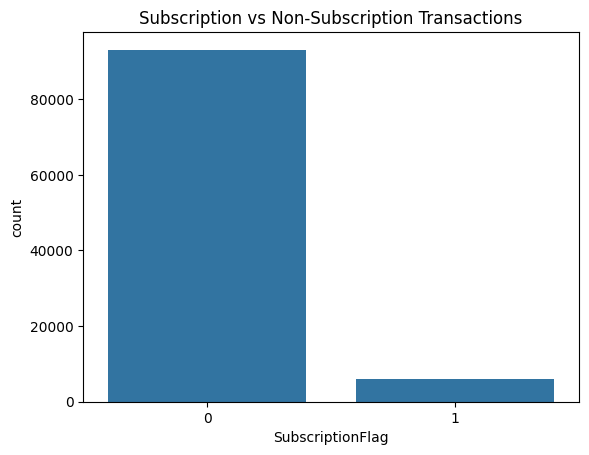

In [53]:
# Subscription vs Non-Subscription Count
sns.countplot(data=df, x="SubscriptionFlag")
plt.title("Subscription vs Non-Subscription Transactions")
plt.show()

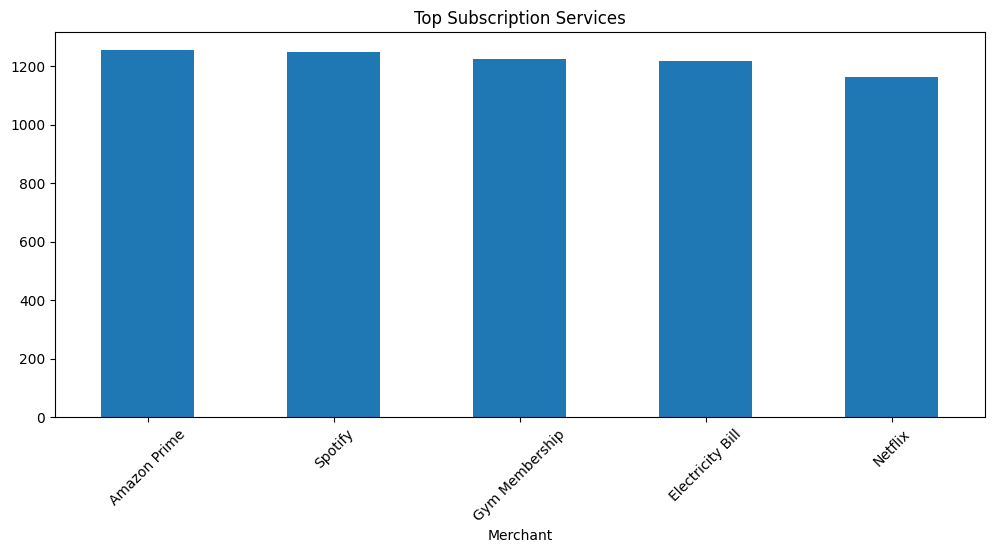

In [55]:
# Most Common Subscription Services
subs = df[df["SubscriptionFlag"] == 1]

subs["Merchant"].value_counts().plot(kind="bar", figsize=(12,5))
plt.title("Top Subscription Services")
plt.xticks(rotation=45)
plt.show()

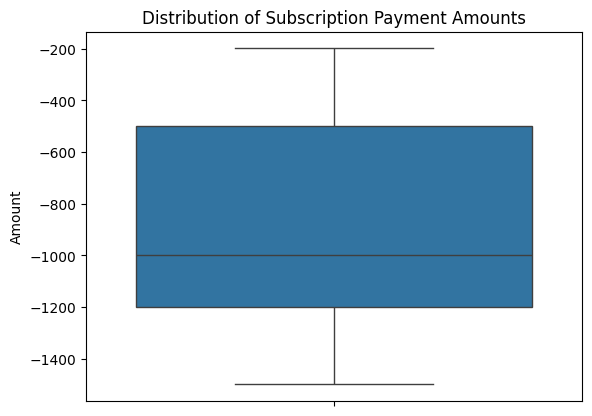

In [56]:
# Subscription Amount Range
sns.boxplot(data=subs, y="Amount")
plt.title("Distribution of Subscription Payment Amounts")
plt.show()

### **Customer Analysis**

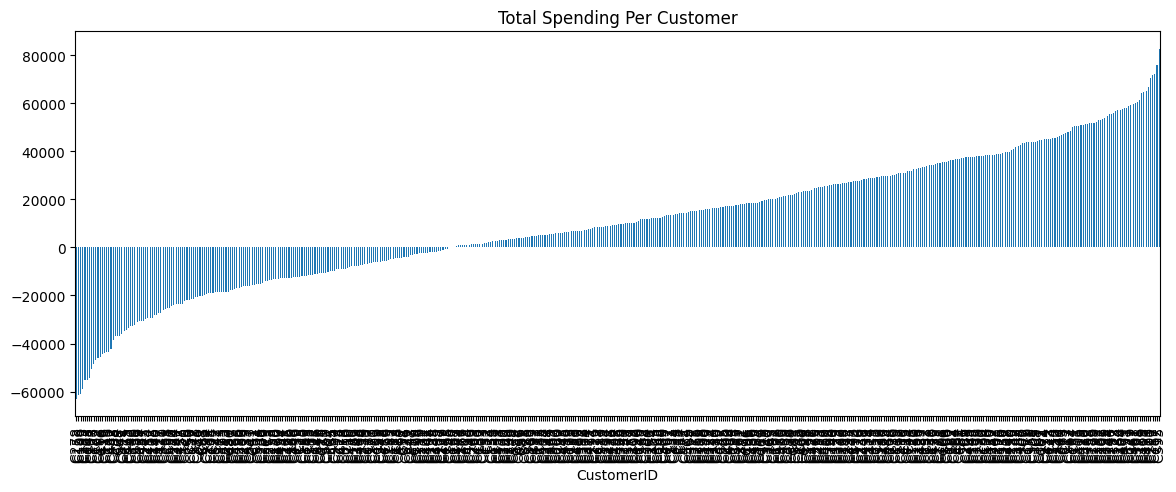

In [ ]:
# Total Spend Per Customer
customer_spend = df.groupby("CustomerID")["Amount"].sum().sort_values()

customer_spend.plot(kind="bar", figsize=(14,5), )
plt.title("Total Spending Per Customer")
plt.show()

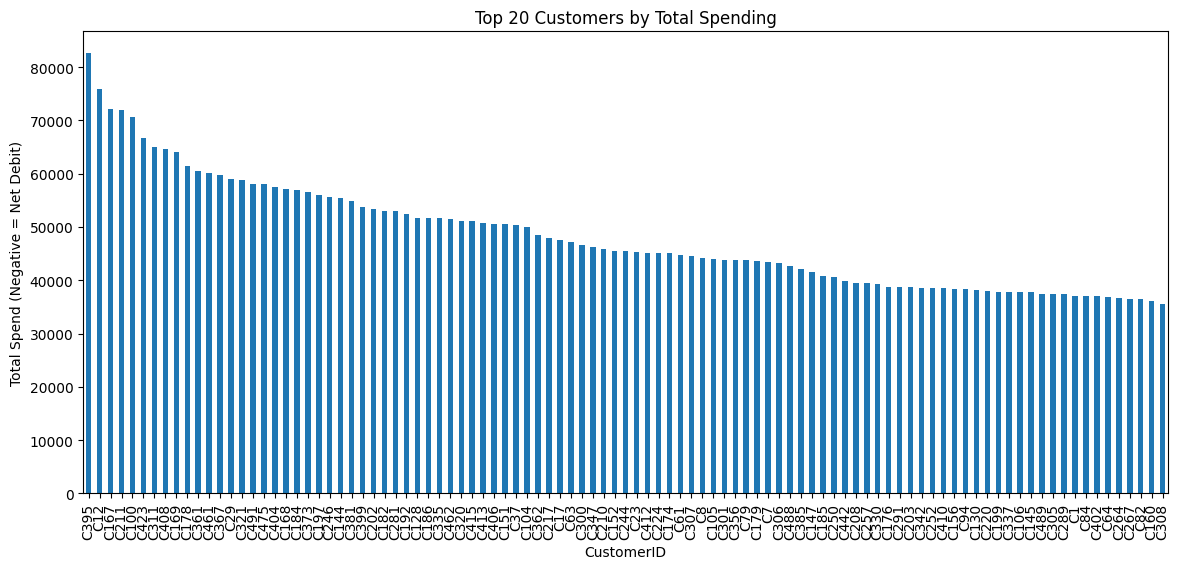

In [84]:
# Total Spend Per Customer
top_spenders = df.groupby("CustomerID")["Amount"].sum().sort_values(ascending=False).head(99)

plt.figure(figsize=(14,6))
top_spenders.plot(kind="bar")
plt.title("Top 20 Customers by Total Spending")
plt.ylabel("Total Spend (Negative = Net Debit)")
plt.show()

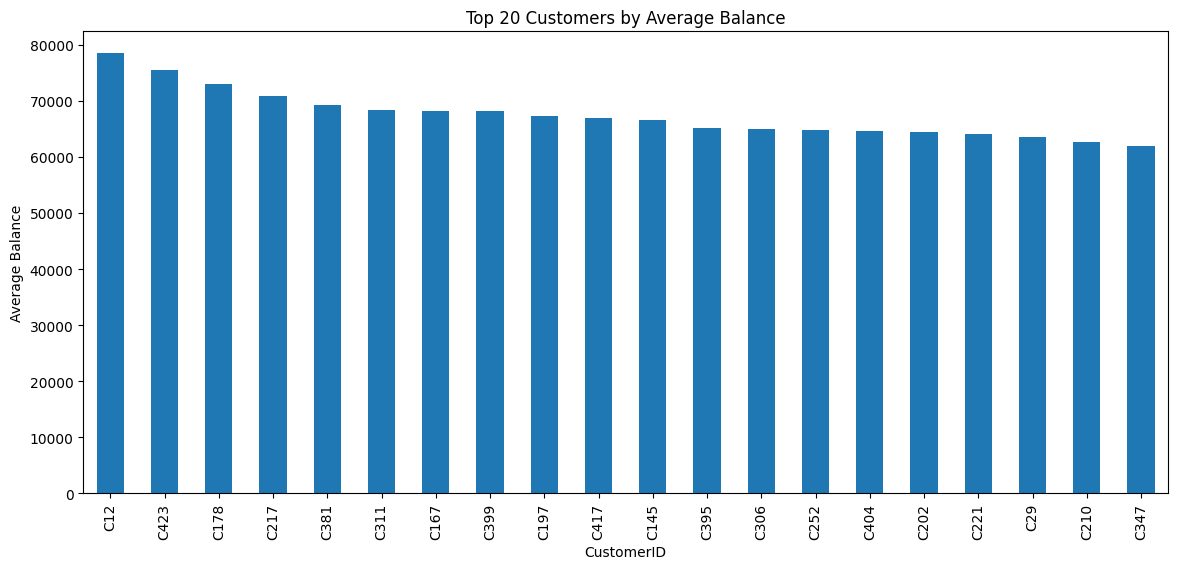

In [ ]:
# Average Balance Per Customer

avg_balance = df.groupby("CustomerID")["Balance"].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14,6))
avg_balance.plot(kind="bar")
plt.title("Top 20 Customers by Average Balance")
plt.ylabel("Average Balance")
plt.show()


### **Merchant Analysis**

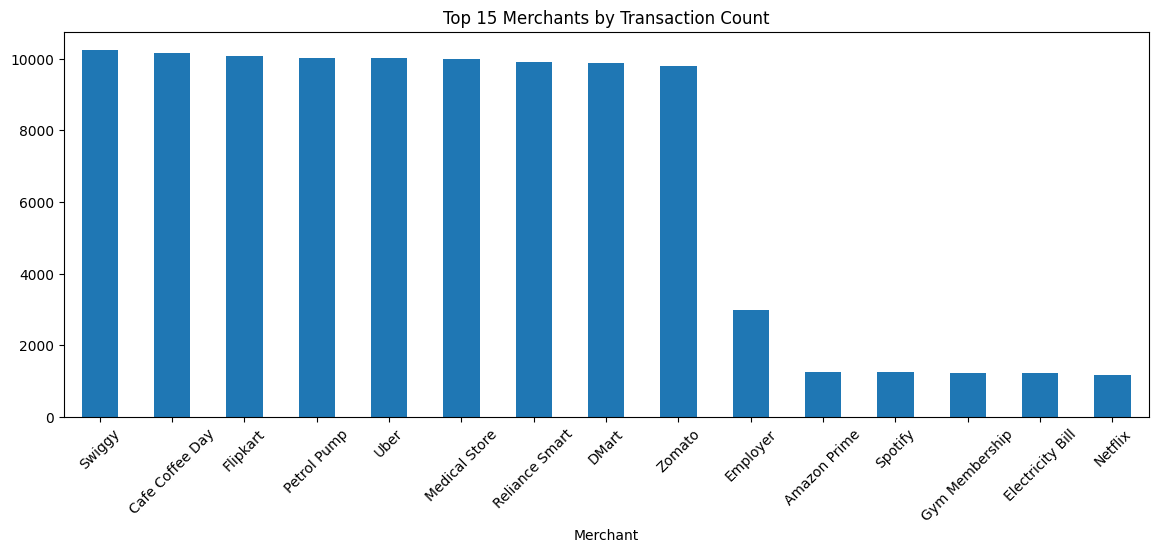

In [68]:
# Top Frequent Merchants
df["Merchant"].value_counts().head(15).plot(kind="bar", figsize=(14,5))
plt.title("Top 15 Merchants by Transaction Count")
plt.xticks(rotation=45)
plt.show()

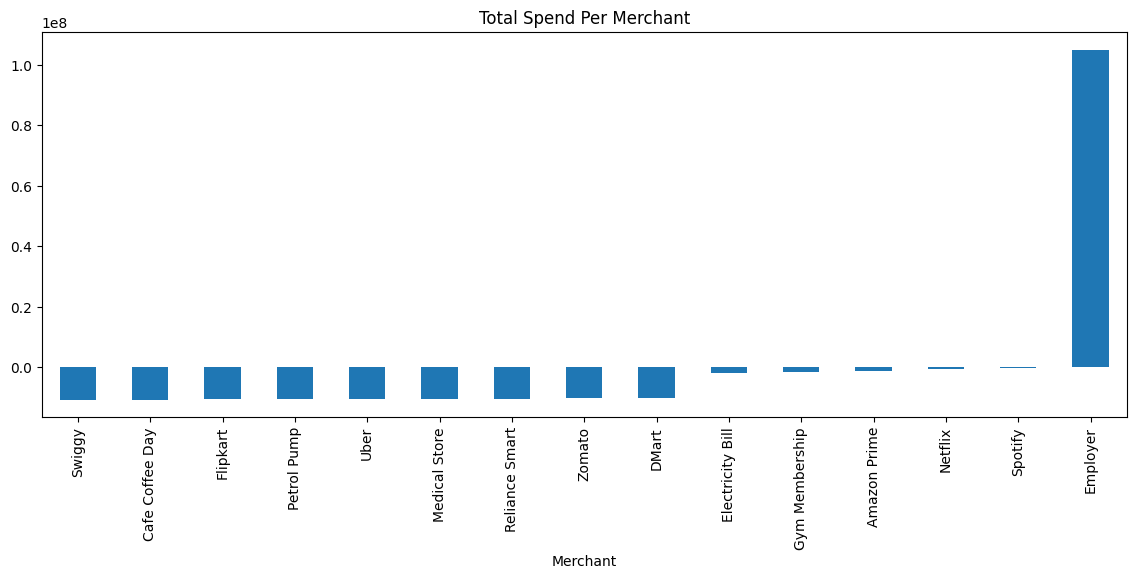

In [70]:
# Spend Per Merchant
df.groupby("Merchant")["Amount"].sum().sort_values().plot(kind="bar", figsize=(14,5))
plt.title("Total Spend Per Merchant")
plt.show()


### **Correlation Analysis**

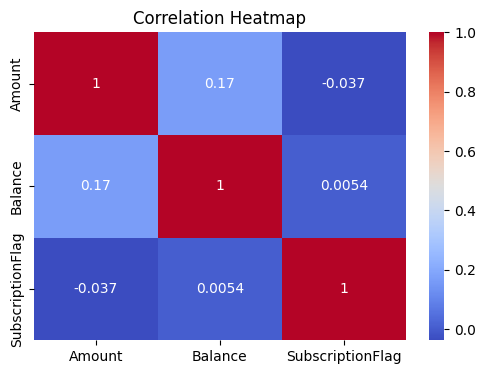

In [71]:
numeric_cols = ["Amount", "Balance", "SubscriptionFlag"]

plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()